In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

:::{admonition} Download
:class: important render-all

This notebook can be downloaded as **{nb-download}`part2_calcium_imaging.ipynb`**. See the button at the top right to download as markdown or pdf.
:::

# Head-direction cells: Part 2 — Calcium imaging

<div class="render-all">

This is **Part 2** of a two-part tutorial comparing two recording modalities — extracellular electrophysiology and calcium imaging — using the same head-direction system in the mouse as a common reference. Both datasets contain head-direction cells, but the signal properties differ: spikes are discrete and fast, while calcium transients are continuous and slow. This gives us a natural testbed to see how the same analysis workflow adapts to different data types.

**Part 1 — Extracellular recordings**, covered in a separate notebook, used spike trains from the anterodorsal thalamic nucleus (ADn) recorded with a silicon probe ([Peyrache et al., 2015](https://www.nature.com/articles/nn.3968)).

This part uses deconvolved fluorescence traces from head-direction cells in the postsubiculum.

With **pynapple** we will:
1. Load the calcium NWB file and extract transients and head-direction
2. Compute tuning curves and visualize them
3. Decode head-direction from population activity with `nap.decode_template`

With **nemos** we will fit a GLM suited to continuous data:
1. Select significantly tuned neurons with a Rayleigh test
2. Fit a `PopulationGLM` with a Gaussian observation model
3. Re-fit with a feature mask to remove self-coupling and compare the coupling filters

The pynapple documentation can be found [here](https://pynapple.org) and the nemos documentation [here](https://nemos.readthedocs.io/en/latest/).

Let's start by importing all the packages.

</div>

In [2]:
import pynapple as nap
import matplotlib.pyplot as plt
import numpy as np
import nemos as nmo
import jax
import workshop_utils
from nemos import _documentation_utils as doc_plots

# LBFGS works better with float64 precision
jax.config.update("jax_enable_x64", True)

# configure pynapple to ignore conversion warning
nap.nap_config.suppress_conversion_warnings = True

# configure some plots
plt.style.use(nmo.styles.plot_style)

## Analyzing calcium imaging with Pynapple

<div class="render-all">

We will now analyze calcium imaging data of head-direction cells recorded in the postsubiculum of the mouse.
We will use a NWB file containing deconvolved calcium events of neurons and the head-direction of the animal over time.
We will study the tuning properties of neurons with tuning curves, decode the head-direction from neural activity,
and fit a GLM with a Gaussian observation model suited to continuous fluorescence data.

</div>

## Load data

<div class="render-all">

Similar to the previous section, we will start by loading a NWB file with `nap.load_file`.
Let's fetch the data first.

</div>

In [3]:
path = workshop_utils.fetch_data("A0670-221213.nwb")
print(path)

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/data/A0670-221213.nwb


<div class="render-user">
```{code-cell} ipython3
data =  # Load NWB file
print(data)
```
</div>

In [4]:
data = nap.load_file(path)

print(data)

A0670-221213
┍━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                  │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ position_time_support │ IntervalSet │
│ RoiResponseSeries     │ TsdFrame    │
│ z                     │ Tsd         │
│ y                     │ Tsd         │
│ x                     │ Tsd         │
│ rz                    │ Tsd         │
│ ry                    │ Tsd         │
│ rx                    │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


<div class="render-all">

There are multiple entries in the NWB file. The calcium transients are stored in the `RoiResponseSeries` entry.
The head-direction of the animal is stored in the `ry` entry. Let's extract them.

</div>

In [5]:
transients = data["RoiResponseSeries"]
angle = data["ry"]
print(transients)

Time (s)          0        1         2         3         4  ...
----------  -------  -------  --------  --------  --------  -----
3.1187      0.27546  0.79973  0.16383   0.20118   0.029255  ...
3.15225     0.26665  0.86751  0.15879   0.23682   0.027189  ...
3.18585     0.25796  0.89419  0.15352   0.25074   0.036514  ...
3.2194      0.24943  0.89513  0.14812   0.25215   0.056273  ...
3.253       0.24111  0.88023  0.14898   0.24651   0.070954  ...
3.28655     0.233    0.85584  0.14858   0.23706   0.081469  ...
3.32015     0.22513  1.0996   0.14715   0.22572   0.088588  ...
...                                                         ...
1203.38945  0.20815  0.17535  0.12126   0.094461  0.87427   ...
1203.42305  0.20247  0.17243  0.11807   0.089918  1.2578    ...
1203.4566   0.19654  0.17056  0.11461   0.085079  1.62      ...
1203.4902   0.19052  0.16645  0.11096   0.080197  1.8811    ...
1203.52375  0.18449  0.16105  0.10717   0.075416  2.0599    ...
1203.55735  0.17851  0.15494  0.10331 

<div class="render-all">

To get an idea of the data, let's visualize the calcium transients of the first two neurons for the first 100 seconds of the recording.
Instead of creating a new `IntervalSet` object, we can use the method `transients.get(0, 100)` to get a restricted version of the `Tsd` object.
Contrary to `restrict`, which takes an `IntervalSet` object as input, `get` can take start and end times directly as input and does not 
update the time support of the output `Tsd` object.

</div>

Text(0, 0.5, 'Fluorescence (a.u.)')

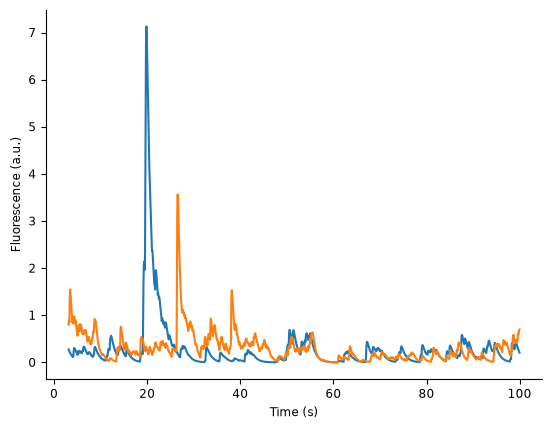

In [6]:
fig = plt.figure()
plt.plot(transients[:,0:2].get(0, 100))
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence (a.u.)")

In [7]:
fig.savefig("../../../_static/_check_figs/01-04.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/01-04.png)
:::
</div>

## Compute tuning curves

<div class="render-all">

We now have calcium transients and a behavioral feature (head-direction). We can compute **tuning curves** — the mean fluorescence of each neuron as a function of head-direction — using the same `nap.compute_tuning_curves` call as in Part 1. Remember to pass `feature_names = ["angle"]` so the output dimension is labelled.

</div>

<div class="render-user">
```{code-cell} ipython3
tuning_curves = nap.compute_tuning_curves(
    data=, # The neural activity as a TsdFrame
    features=, # Which feature? Here the head-direction of the animal
    bins=, # How many bins of feature space? Here 61 angular bins is a good number
    range=, # The min and max of the bin array
    feature_names= # Let's give a name to our feature for better labelling of the output.
    )
tuning_curves
```
</div>

In [8]:
tuning_curves = nap.compute_tuning_curves(
    data=transients,
    features=angle,
    bins=61,
    epochs=angle.time_support,
    range=(0, 2 * np.pi),
    feature_names=["angle"]
    )

tuning_curves

<xarray.DataArray (unit: 65, angle: 61)> Size: 32kB
array([[0.336294  , 0.39249376, 0.28825878, ..., 0.36234269, 0.2708909 ,
        0.28310301],
       [0.05395929, 0.04359246, 0.04214995, ..., 0.07306646, 0.06231189,
        0.05681652],
       [0.15342062, 0.17939499, 0.15450186, ..., 0.1853742 , 0.11779423,
        0.12548764],
       ...,
       [0.09231561, 0.09080612, 0.06466286, ..., 0.13556026, 0.1133827 ,
        0.09577019],
       [0.10206325, 0.08374734, 0.07383455, ..., 0.11335814, 0.10032206,
        0.09266054],
       [0.09586888, 0.13690644, 0.16440948, ..., 0.0797701 , 0.08365685,
        0.0929572 ]], shape=(65, 61))
Coordinates:
  * unit     (unit) int64 520B 0 1 2 3 4 5 6 7 8 ... 56 57 58 59 60 61 62 63 64
  * angle    (angle) float64 488B 0.0515 0.1545 0.2575 ... 6.026 6.129 6.232
Attributes:
    occupancy:  [1898. 2249. 2064. 1962. 2081. 2249. 2544. 2511. 2045. 2498. ...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         120.00514660424693

## Visualize tuning curves

<div class="render-all">

Let's visualize the tuning curves of the first two neurons.

</div>

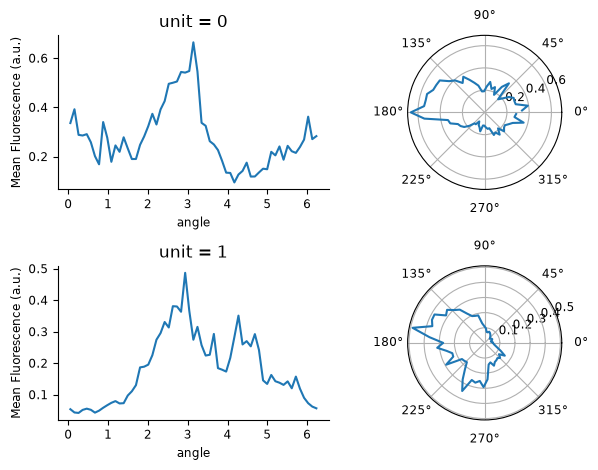

In [9]:
fig = plt.figure()
plt.subplot(221)
tuning_curves[0].plot()
plt.ylabel("Mean Fluorescence (a.u.)")
plt.subplot(222, projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[0].values)
plt.subplot(223)
tuning_curves[1].plot()
plt.ylabel("Mean Fluorescence (a.u.)")
plt.subplot(224, projection='polar')
plt.plot(tuning_curves.angle, tuning_curves[1].values)
plt.tight_layout()

In [10]:
fig.savefig("../../../_static/_check_figs/01-05.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/01-05.png)
:::
</div>

## Decode head-direction from neural activity

<div class="render-all">

Now that we have the tuning curves, we can use them to decode the head-direction of the animal from the neural activity.
Pynapple provides two functions to do this: `nap.decode_bayes` for spike counts and `nap.decode_template` for event rates or continuous data.
Since the data are calcium transients and not spike counts, we will use the template matching method.

**Question:** Can you decode the head-direction of the animal using the function `nap.decode_template` and call the variable `decoded_angle`?

We will use the epoch `epochs = nap.IntervalSet(start=50, end=150)` to restrict the decoding to 100 seconds of the recording.

</div>

<div class="render-user">
```{code-cell} ipython3
epochs = nap.IntervalSet(start=50, end=150)
decoded_angle, dist = nap.decode_template(
    tuning_curves= , # The tuning curves as an xarray object
    data= , # The neural activity as a TsdFrame
    bin_size= , # The bin size for decoding. Here I suggest 0.1 second
    metric= , # The metric to compare neural activity to tuning curves. Here I suggest "correlation"
    epochs=epochs
    )
```
</div>

In [11]:
epochs = nap.IntervalSet(start=50, end=150)
decoded_angle, dist = nap.decode_template(
    tuning_curves=tuning_curves,
    data=transients,
    bin_size=0.1,
    metric="correlation",
    epochs=epochs
    )

/home/jenkins/agent/workspace/orse_ccn-software-fens-2026_main/.venv/lib/python3.12/site-packages/pynapple/process/decoding.py:48: UserWarning: passed bin_size is different from actual data bin size.
  warnings.warn("passed bin_size is different from actual data bin size.")


<div class="render-all">

Let's compare the decoded angle against the true head-direction and inspect the decoder's confidence across angles over time.

</div>

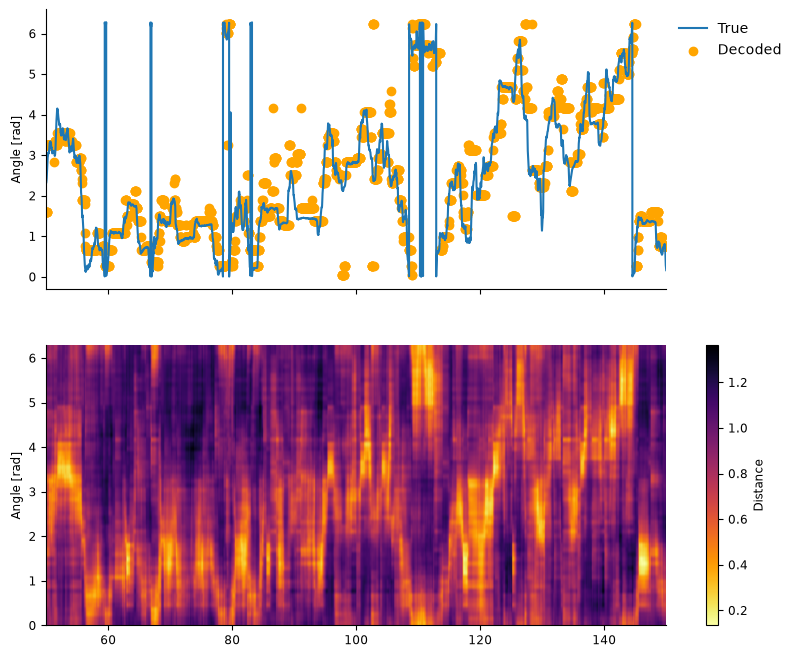

In [12]:
fig, (ax1, ax2) = plt.subplots(figsize=(8, 8), nrows=2, ncols=1, sharex=True)
ax1.plot(angle.restrict(epochs), label="True")
ax1.scatter(decoded_angle.times(), decoded_angle.values, label="Decoded", c="orange")
ax1.legend(frameon=False, bbox_to_anchor=(1.0, 1.0))
ax1.set_ylabel("Angle [rad]")

im = ax2.imshow(
    dist.values.T,
    aspect="auto",
    origin="lower",
    cmap="inferno_r",
    extent=(epochs.start[0], epochs.end[0], 0.0, 2*np.pi)
)
ax2.set_ylabel("Angle [rad]")
cbar_ax2 = fig.add_axes([0.95, ax2.get_position().y0, 0.015, ax2.get_position().height])
fig.colorbar(im, cax=cbar_ax2, label="Distance")

In [13]:
fig.savefig("../../../_static/_check_figs/01-06.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/01-06.png)
:::
</div>

<div class="render-all">

The top panel overlays the decoded angle on the true head-direction. The bottom panel shows the template-matching distance at each candidate angle over time — the trough tracks the decoded position. Try different `metric` values (`"euclidean"`, `"manhattan"`, `"correlation"`, `"jensenshannon"`, `"cosine"`) to see how the choice affects decoding accuracy.

</div>

## Modelling calcium imaging data with GLM

<div class="render-all">

Calcium imaging data differs from spike data in two key ways: the signal is continuous-valued (fluorescence rather than counts), and its dynamics are slower due to calcium indicator kinetics. These differences call for two model changes: a Gaussian observation model instead of Poisson, and a basis window tuned to the slower temporal structure.

</div>

## Preprocessing the data

<div class="render-all">

Before fitting the GLM we keep only neurons significantly tuned to head-direction (Rayleigh test, p < 0.01). This reduces dimensionality and speeds up fitting.

</div>

In [14]:
C = np.sum(tuning_curves.values * np.cos(tuning_curves.angle.values), axis=1) / np.sum(tuning_curves.values, axis=1)
S = np.sum(tuning_curves.values * np.sin(tuning_curves.angle.values), axis=1) / np.sum(tuning_curves.values, axis=1)
R = np.sqrt(C**2 + S**2)
Z = tuning_curves.shape[1] * R**2
p_value = np.exp(-Z)

tokeep_neurons = np.where(p_value < 0.01)[0]
transients = transients[:, tokeep_neurons]
tuning_curves = tuning_curves[tokeep_neurons]
print(f"Number of neurons after tuning selection: {transients.shape[1]}")

Number of neurons after tuning selection: 16


<div class="render-all">

Finally, we sort the neurons based on their preferred head-direction.

</div>

In [15]:
pref_ang = tuning_curves.idxmax(dim="angle")
sort_idx = np.argsort(pref_ang.values)
transients = transients[:, sort_idx]
tuning_curves = tuning_curves[sort_idx]
pref_ang = pref_ang[sort_idx]
transients.set_info(pref_ang=pref_ang)
print(transients)

Time (s)    64         6           17       49        1        ...
----------  ---------  ----------  -------  --------  -------  -----
3.1187      0.1564     8.0399e-11  0.11318  0.17587   0.79973  ...
3.15225     0.15096    7.5078e-11  0.10589  0.16596   0.86751  ...
3.18585     0.14533    7.0109e-11  0.10145  0.1566    0.89419  ...
3.2194      0.13983    6.5469e-11  0.14243  0.15677   0.89513  ...
3.253       0.13452    6.1136e-11  0.16411  0.15343   0.88023  ...
3.28655     0.12941    5.709e-11   0.17343  0.24614   0.85584  ...
3.32015     0.12449    5.3312e-11  0.17497  0.25991   1.0996   ...
...                                                            ...
1203.38945  0.0053469  0.069231    0.15937  0.090531  0.17535  ...
1203.42305  0.0051438  0.064979    0.15854  0.085426  0.17243  ...
1203.4566   0.0049484  0.060901    0.15421  0.080609  0.17056  ...
1203.4902   0.0047604  0.057022    0.14785  0.076063  0.16645  ...
1203.52375  0.0045795  0.053351    0.1404   0.071773  0.1610

## Basis functions for calcium data

<div class="render-all">

We use the same `RaisedCosineLogConv` basis but with fewer, broader basis functions over a 0.5 s window — appropriate for the slower dynamics of calcium signals compared to spikes.

**Question: Can you define a `RaisedCosineLogConv` basis and name it `calcium_basis`?**

Basis parameters:
- 4 basis functions.
- Window size of 0.5 sec.

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_window_size_sec = 0.5
calcium_window_size = int(calcium_window_size_sec * transients.rate)
calcium_basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs= , # Number of basis functions
    window_size=calcium_window_size
)
calcium_basis
```
</div>

In [16]:
calcium_window_size_sec = 0.5
calcium_window_size = int(calcium_window_size_sec * transients.rate)
calcium_basis = nmo.basis.RaisedCosineLogConv(
    n_basis_funcs=4, window_size=calcium_window_size
)
print(calcium_window_size)
calcium_basis

14


,n_basis_funcs,4
,window_size,14
,time_scaling,50.0
,conv_kwargs,{}
,width,2.0
,enforce_decay_to_zero,True
,label,'RaisedCosineLogConv'


## Preparing the features

<div class="render-all">

We can convolve the calcium transients with the basis functions to get the feature matrix.

**Question: Can you convolve all neurons and call the output `calcium_convolved`?**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_convolved = calcium_basis.compute_features( ) # Parameter is the calcium transients
print(f"Convolved calcium shape: {calcium_convolved.shape}")
```
</div>

In [17]:
calcium_convolved = calcium_basis.compute_features(transients)
print(f"Convolved calcium shape: {calcium_convolved.shape}")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Convolved calcium shape: (35757, 64)


## Fitting a Gaussian Population GLM

<div class="render-all">

We fit a `PopulationGLM` with a Gaussian observation model, which is appropriate for continuous-valued fluorescence data. As before, we split the recording into a training first-half and a testing second-half.

</div>

In [18]:
duration = calcium_convolved.time_support.tot_length("s")
start = calcium_convolved.time_support["start"]
end = calcium_convolved.time_support["end"]
training_ep = nap.IntervalSet(start, start + duration / 2)
testing_ep = nap.IntervalSet(start + duration / 2, end)

<div class="render-all">

**Question: Can you fit a `PopulationGLM` with a Gaussian observation model, Ridge regularization, strength 0.001, and LBFGS solver? Call it `calcium_model`.**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_model = nmo.glm.PopulationGLM(
    observation_model= , # Observation model type
    regularizer= , # Regularizer type
    solver_name= , # Solver name
    regularizer_strength= , # Regularization strength
    solver_kwargs={"maxiter": 5000}
    ).fit( , ) # Parameters are the convolved feature matrix and the calcium transients during training epoch
print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")
```
</div>

In [19]:
calcium_model = nmo.glm.PopulationGLM(
    observation_model="Gaussian",
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.001,
    solver_kwargs={"maxiter": 5000}
    ).fit(calcium_convolved.restrict(training_ep), transients.restrict(training_ep))

print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")

Calcium model coefficients shape: (64, 16)


## Predicting and visualizing the results

<div class="render-all">

**Question:** Can you predict the calcium signals on the test epoch and call the result `calcium_predicted`?

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_predicted = calcium_model.predict( ) # Parameter is the convolved feature matrix restricted to the testing epoch
```
</div>

In [20]:
calcium_predicted = calcium_model.predict(calcium_convolved.restrict(testing_ep))

<div class="render-all">

Let's overlay the predicted and actual fluorescence traces for one neuron to assess how well the model tracks the signal.

</div>

Text(0, 0.5, 'Fluorescence Intensity')

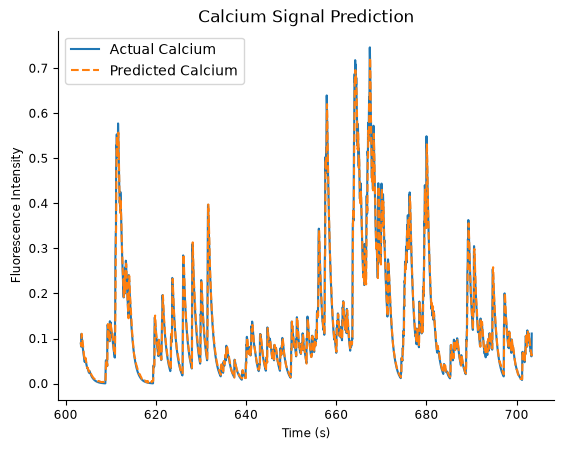

In [21]:
ep_to_plot = nap.IntervalSet(testing_ep.start[0], testing_ep.start[0] + 100)

fig = plt.figure()
plt.plot(transients.restrict(ep_to_plot)[:,0], label="Actual Calcium")
plt.plot(calcium_predicted.restrict(ep_to_plot)[:,0], '--', label="Predicted Calcium")
plt.legend()
plt.title("Calcium Signal Prediction")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity")

In [22]:
fig.savefig("../../../_static/_check_figs/02-12.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/02-12.png)
:::
</div>

<div class="render-all">

As in Part 1, we project the coefficients back through the basis kernels to recover the coupling filters.

</div>

In [23]:
calcium_weights_dict = calcium_basis.split_by_feature(calcium_model.coef_, axis=0)
calcium_weights = calcium_weights_dict["RaisedCosineLogConv"]
_, basis_kernels = calcium_basis.evaluate_on_grid(calcium_window_size)
calcium_responses = np.einsum("jki,tk->ijt", calcium_weights, basis_kernels)
print(calcium_responses.shape)

(16, 16, 14)


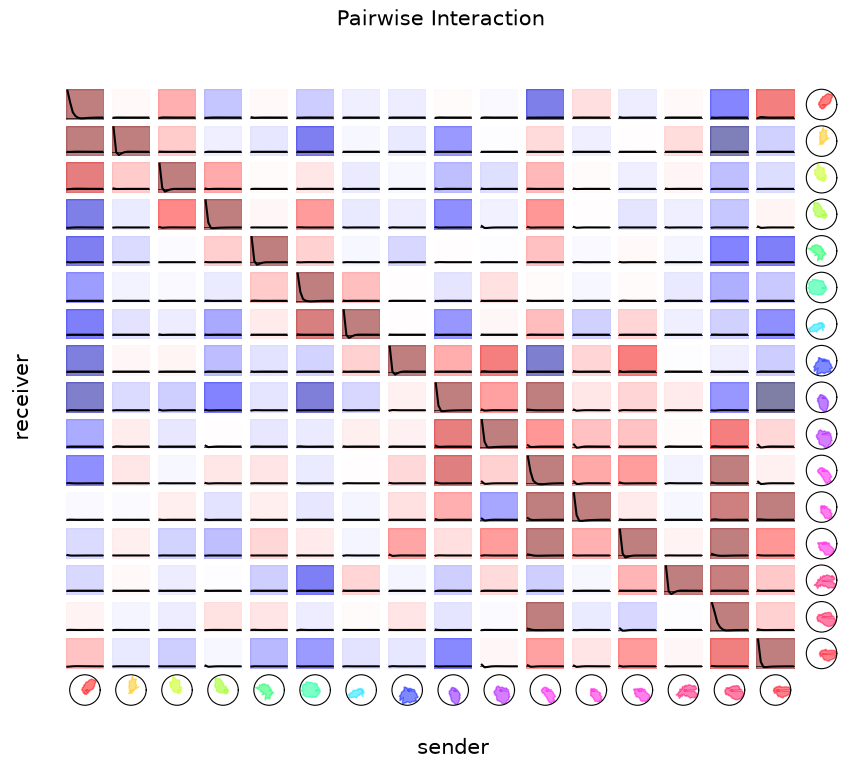

In [24]:
fig = workshop_utils.plot_coupling_filters(calcium_responses, tuning_curves)

In [25]:
fig.savefig("../../../_static/_check_figs/02-13.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/02-13.png)
:::
</div>

<div class="render-all">

The self-coupling (diagonal) dominates because the GLM is largely fitting each neuron's own calcium decay. The slow indicator kinetics make past self-activity a very strong predictor of the current value, swamping the between-neuron interactions.

</div>

## Fitting a population GLM with masking (no self-coupling)

<div class="render-all">

To reveal cross-neuron interactions we need to block self-connections. We do this with a binary feature mask: a matrix of ones with zeros on the diagonal. Each row of the feature matrix is multiplied element-wise by the corresponding mask row, zeroing out the self-history predictors. We then tile the mask across basis functions to match the full feature dimensionality.

</div>

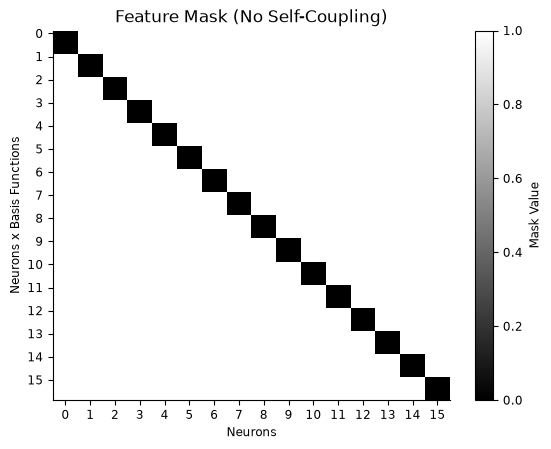

In [26]:
n_neurons = transients.shape[1]
mask = np.ones((n_neurons, n_neurons))
mask = mask - np.eye(n_neurons)
mask = np.repeat(mask, calcium_basis.n_basis_funcs, axis=0)

fig = plt.figure()
plt.imshow(mask, cmap="gray", aspect="auto", interpolation='none')
plt.xticks(ticks=np.arange(n_neurons), labels=np.arange(n_neurons))
plt.yticks(
    ticks=np.arange(0, n_neurons * calcium_basis.n_basis_funcs, calcium_basis.n_basis_funcs),
    labels=np.arange(n_neurons)
)
plt.title("Feature Mask (No Self-Coupling)")
plt.xlabel("Neurons")
plt.ylabel("Neurons x Basis Functions")
plt.colorbar(label="Mask Value")

<div class="render-all">

Now we can fit the `PopulationGLM` again using this feature mask to prevent self-coupling.

**Question: Can you re-fit `calcium_model` adding the `feature_mask` argument?**

</div>

<div class="render-user">
```{code-cell} ipython3
calcium_model = nmo.glm.PopulationGLM(
    observation_model= , # Observation model type
    regularizer= , # Regularizer type
    solver_name= , # Solver name
    regularizer_strength= , # Regularization strength
    feature_mask= , # The feature mask to prevent self-coupling
    solver_kwargs={"maxiter": 5000}
    ).fit( , ) # Parameters are the convolved feature matrix and the calcium transients during training epoch
print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")
```
</div>

In [27]:
calcium_model = nmo.glm.PopulationGLM(
    observation_model="Gaussian",
    regularizer="Ridge",
    solver_name="LBFGS",
    regularizer_strength=0.001,
    feature_mask=mask,
    solver_kwargs={"maxiter": 5000}
    ).fit(calcium_convolved.restrict(training_ep), transients.restrict(training_ep))

print(f"Calcium model coefficients shape: {calcium_model.coef_.shape}")

Calcium model coefficients shape: (64, 16)


## Visualizing the coupling filters without self-coupling

<div class="render-all">

With self-coupling removed, the between-neuron interactions become visible. Let's extract and plot the filters.

</div>

In [28]:
calcium_weights_dict = calcium_basis.split_by_feature(calcium_model.coef_, axis=0)
calcium_weights = calcium_weights_dict["RaisedCosineLogConv"]
_, basis_kernels = calcium_basis.evaluate_on_grid(calcium_window_size)
calcium_responses_noself = np.einsum("jki,tk->ijt", calcium_weights, basis_kernels)
print(calcium_responses_noself.shape)

(16, 16, 14)


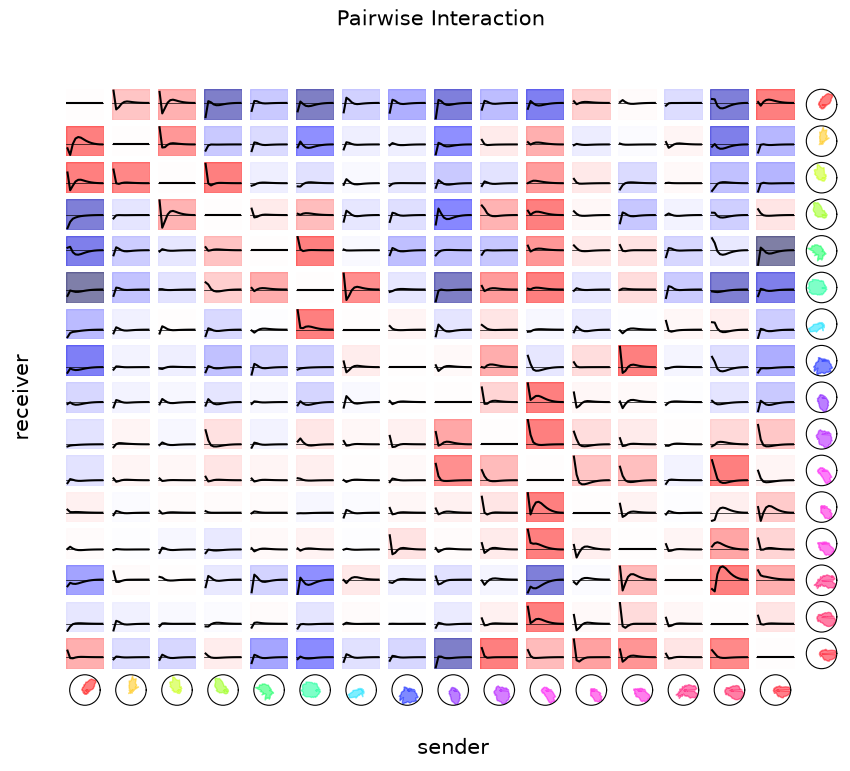

In [29]:
fig = workshop_utils.plot_coupling_filters(calcium_responses_noself, tuning_curves)

In [30]:
fig.savefig("../../../_static/_check_figs/02-14.png")

<div class="render-user">
:::{admonition} Figure check
:class: dropdown
![](../../../_static/_check_figs/02-14.png)
:::
</div>

## Conclusion

<div class="render-all">

You have applied the same modelling framework — pynapple for data handling and nemos for GLM fitting — to two very different recording modalities. The core workflow is identical; what changes is the observation model and the basis parameterization.

**Things to explore:**
- Vary `regularizer_strength` or switch to Lasso regularization and observe how the coupling filters change.
- Add the head-direction signal as an external covariate alongside the spike history and compare the two models' predictions.
- Downsample the calcium traces with `transients.bin_average(bin_size)` and re-fit to see how temporal resolution affects the results.
- Replace `RaisedCosineLogConv` with `RaisedCosineLinearConv` and compare the filter shapes.

</div>